# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

### Logistic Regression Classifier

This notebook implements a supervised machine learning workflow to predict 30-day price movements using Logistic Regression.

**Data source:** `model_data.csv` — pre-processed by `DataPipeline.ipynb`

- Cleaning, feature engineering, multicollinearity reduction, and target creation are handled upstream
- This notebook focuses only on model training and evaluation

---

**Target: Price_Direction_30d**

- `1` → Positive 30-day forward ROC (price goes up)
- `0` → Non-positive 30-day forward ROC (price flat or down)

### **Initial Imports and Basic Settings**

We import all necessary libraries for:
- Data handling
- Visualization
- Model training
- Performance evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

### **Data Loading**

We load the **processed dataset** generated from the data pipeline.

This dataset already contains:
- Selected technical indicators
- Cleaned and aligned features
- Target variable for classification

In [2]:
df = pd.read_csv('../model_data.csv')

df.head()

,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.000043,0.165902,53.267613,0.070849,-0.035639,59.007924,-0.794889,1.096819,-2430.159359,0
1,1999-04-06,-0.000018,0.171081,50.304723,0.071632,-0.055301,43.711443,-3.070597,0.777656,-2246.215563,1
2,1999-04-07,-0.000038,0.157911,48.005570,0.067320,0.026581,48.084269,-2.457141,1.027057,-2462.768192,0
3,1999-04-08,-0.000019,0.153657,55.179098,0.065174,0.045705,61.198544,-1.357794,1.593394,-2537.529485,0
4,1999-04-09,0.000012,0.154960,56.664675,0.063724,0.026737,75.403923,0.664012,0.597464,-2526.145480,0


### **Dataset Overview**

We inspect the dataset structure to verify:
- Number of rows and columns
- Feature availability
- Data types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6479 entries, 0 to 6478
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6479 non-null   str    
 1   MACD_Signal          6479 non-null   float64
 2   BB_Width             6479 non-null   float64
 3   RSI_lag1             6479 non-null   float64
 4   ATR_Pct              6479 non-null   float64
 5   SMA20_Dist           6479 non-null   float64
 6   Stoch_K              6479 non-null   float64
 7   ROC_roll5_mean       6479 non-null   float64
 8   Volume_Ratio         6479 non-null   float64
 9   CCI                  6479 non-null   float64
 10  Price_Direction_30d  6479 non-null   int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 556.9 KB


## Feature selection and target definition

We define the feature set and target variable used for model training.

These features are derived from technical indicators created during the data pipeline stage.

In [4]:
FEATURES = [
    "MACD_Signal",
    "BB_Width",
    "RSI_lag1",
    "ATR_Pct",
    "SMA20_Dist",
    "Stoch_K",
    "ROC_roll5_mean",
    "Volume_Ratio",
    "CCI"
]

TARGET = "Price_Direction_30d"

X = df[FEATURES]
y = df[TARGET]

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Feature shape: (6479, 9)
Target distribution:
 Price_Direction_30d
1    0.616762
0    0.383238
Name: proportion, dtype: float64


## Train-test split

We split the dataset into training, validation, and test sets.

The split is performed without shuffling to preserve temporal order and avoid data leakage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    shuffle=False
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")

print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train: 5507  Test: 972

Train class balance:
Price_Direction_30d
1    0.612
0    0.388
Name: proportion, dtype: float64

Test class balance:
Price_Direction_30d
1    0.646
0    0.354
Name: proportion, dtype: float64


### Feature scaling

Logistic Regression requires standardized features for stable training.

We apply StandardScaler to normalize feature distributions.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train with RandomizedSearchCV

- We tune Logistic Regression hyperparameters using TimeSeriesSplit cross-validation, this goes hand in hand with the temporal order
- Random split isn't preferred as it shuffles randomly and cause data leakage.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Base model
log_reg = LogisticRegression(
    solver='lbfgs',         
    max_iter=2000,
    class_weight='balanced'
)

# Hyperparameter distribution 
param_dist = {
    "C": loguniform(1e-3, 10)
}

# Randomized Search
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
log_search.fit(X_train_scaled, y_train)

# Best model
best_model = log_search.best_estimator_

# Print best parameter
print("\nBest C:", log_search.best_params_["C"])

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best C: 0.006290644294586149


## Performance across all splits

- We evaluate model performance on both training and test sets using standard classification metrics and ROC-AUC.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Probabilities (needed for ROC-AUC)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_train_proba = best_model.predict_proba(X_train_scaled)[:, 1]
# Metrics 
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1-Score': f1_score,
}

# Print table
print(f"\n{'Metric':<12} {'Train':>10} {'Test':>10}")
print("-" * 35)

for name, fn in metrics.items():
    tr = fn(y_train, y_train_pred)
    te = fn(y_test, y_test_pred)
    print(f"{name:<12} {tr:>10.4f} {te:>10.4f}")

# ROC-AUC (both train and test)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)
print(f"\n{'ROC-AUC':<12} {roc_auc_train:>10.4f} {roc_auc_test:>10.4f}")
print("Overfit gap remains negligible 0.0067")



Metric            Train       Test
-----------------------------------
Accuracy         0.5497     0.5432
Precision        0.6498     0.6420
Recall           0.5719     0.6624
F1-Score         0.6083     0.6520

ROC-AUC          0.5684     0.4914
Overfit gap remains negligible 0.0067


## Confusion Matrix and ROC Curve

- We visualize classification performance using confusion matrix and ROC curve.
- As a KPI, Precision is really important as a high number of false positives can backfire and result in trading losses
- ROC-AUC score is also important as it shows the classificaton power of our model. 0.50 being close to random

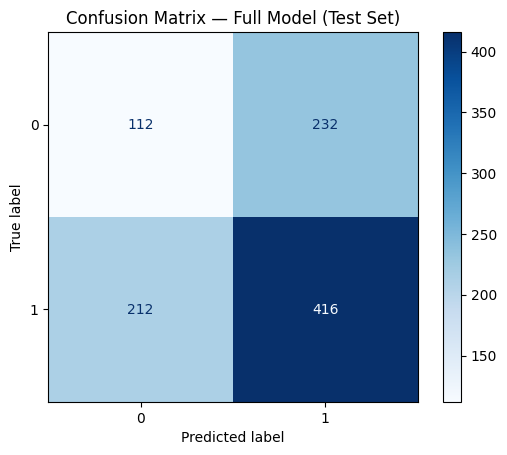

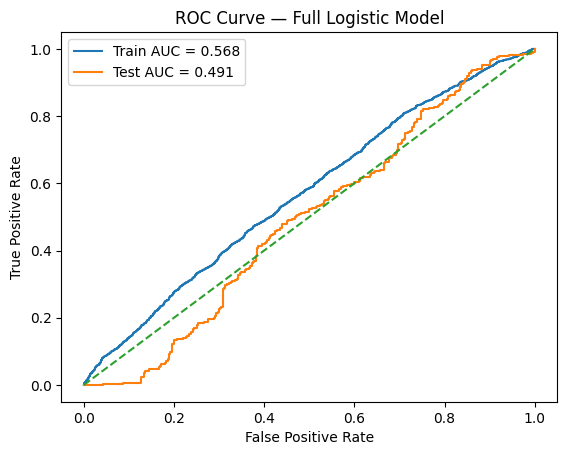

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ======================
# CONFUSION MATRIX (TEST)
# ======================
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix — Full Model (Test Set)")
plt.show()


# ======================
# ROC CURVE (TRAIN + TEST)
# ======================

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
train_auc = roc_auc_score(y_train, y_train_proba)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Full Logistic Model")

plt.legend()
plt.show()

### Feature Importance (Logistic Regression Coefficients)

We interpret feature importance using model coefficients.
Higher absolute values indicate stronger influence on predictions.

          Feature  Coefficient  Abs_Coefficient
8             CCI    -0.155659         0.155659
3         ATR_Pct     0.117774         0.117774
2        RSI_lag1     0.110254         0.110254
0     MACD_Signal     0.105451         0.105451
4      SMA20_Dist     0.052926         0.052926
5         Stoch_K    -0.050482         0.050482
1        BB_Width    -0.049575         0.049575
6  ROC_roll5_mean     0.022460         0.022460
7    Volume_Ratio    -0.009600         0.009600


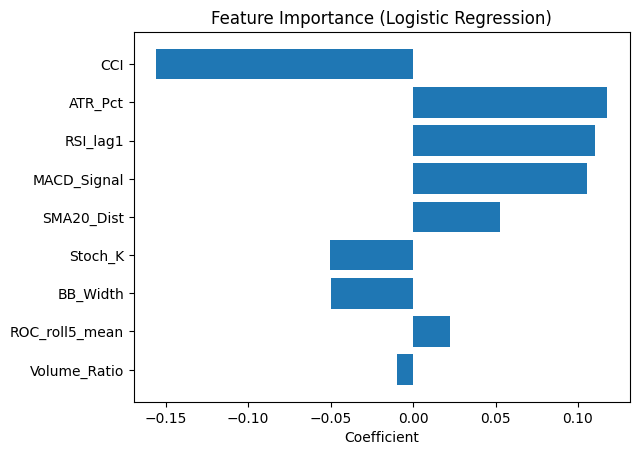

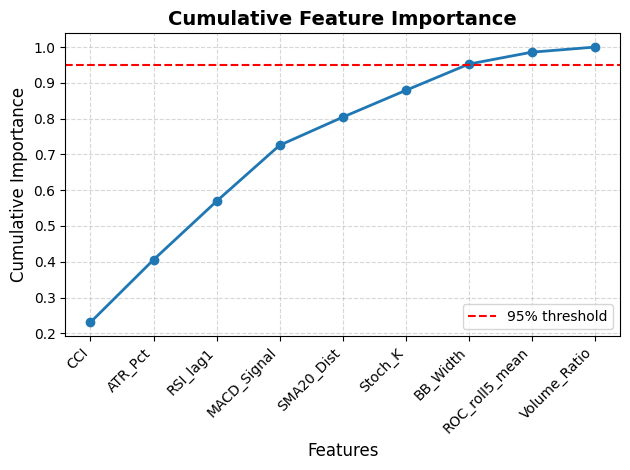

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract coefficients
coef = best_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Display
print(feature_importance)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fi = feature_importance.copy()

# Normalize importance
fi['Normalized'] = fi['Abs_Coefficient'] / fi['Abs_Coefficient'].sum()

# Cumulative sum
fi['Cumulative'] = fi['Normalized'].cumsum()


import matplotlib.pyplot as plt

plt.figure()

# Line plot
plt.plot(fi['Feature'], fi['Cumulative'], marker='o', linewidth=2)

# 95% threshold line
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')

# Labels
plt.title("Cumulative Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Cumulative Importance", fontsize=12)

# Rotate x labels f
plt.xticks(rotation=45, ha='right')

# Grid for clarity
plt.grid(True, linestyle='--', alpha=0.5)

# Legend
plt.legend()

# Tight layout to avoid cut-off labels
plt.tight_layout()

plt.show()

### Dropping features which has low contribution to explaining the model

We ranked features using logistic regression coefficients and select features contributing to 95% cumulative importance

In [11]:

# ===== Feature Importance + Cumulative Selection (95%) =====

import pandas as pd
import numpy as np

# 1. Extract coefficients from best model
coef = best_model.coef_[0]

# 2. Create feature importance dataframe (ABS values)
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef,
    'Importance': np.abs(coef)
})

# 3. Sort by importance
feat_imp_sorted = feat_imp.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# 4. Compute cumulative importance (normalized)
feat_imp_sorted['Cumulative'] = (
    feat_imp_sorted['Importance'].cumsum() /
    feat_imp_sorted['Importance'].sum()
)

# 5. Find cutoff (first index where cumulative >= 95%)
cutoff_idx = (feat_imp_sorted['Cumulative'] >= 0.95).idxmax()

# 6. Final selected features
FEATURES_FINAL = feat_imp_sorted.loc[:cutoff_idx, 'Feature'].tolist()

# 7. Dropped features
DROPPED_FEATURES = feat_imp_sorted.loc[cutoff_idx + 1:, 'Feature'].tolist()

# 8. Display 
print("=== Selected Features (95% cumulative importance) ===")
print(feat_imp_sorted.loc[:cutoff_idx, ['Feature', 'Importance', 'Cumulative']].to_string(index=False))

print("\n=== Dropped Features (low contribution) ===")
print(feat_imp_sorted.loc[cutoff_idx + 1:, ['Feature', 'Importance', 'Cumulative']].to_string(index=False))

print("\nFinal feature list:")
print(FEATURES_FINAL)


=== Selected Features (95% cumulative importance) ===
    Feature  Importance  Cumulative
        CCI    0.155659    0.230886
    ATR_Pct    0.117774    0.405578
   RSI_lag1    0.110254    0.569116
MACD_Signal    0.105451    0.725530
 SMA20_Dist    0.052926    0.804034
    Stoch_K    0.050482    0.878913
   BB_Width    0.049575    0.952446

=== Dropped Features (low contribution) ===
       Feature  Importance  Cumulative
ROC_roll5_mean     0.02246    0.985761
  Volume_Ratio     0.00960    1.000000

Final feature list:
['CCI', 'ATR_Pct', 'RSI_lag1', 'MACD_Signal', 'SMA20_Dist', 'Stoch_K', 'BB_Width']


### Retraining on Reduced Feature Set

The model is retrained on 7 features

In [12]:
# ===============================
# Logistic Regression (Reduced Features)
# ===============================

X2 = df[FEATURES_FINAL]
y2 = df[TARGET]

# Time-based split — same structure as full model, no val set
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.15, shuffle=False
)

# Scaling (IMPORTANT for Logistic Regression)
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

# Verify splits match full model
print(f"Train: {len(X2_train)}  |  Test: {len(X2_test)}")
print(f"Train date: {df.loc[X2_train.index[0], 'Date']} -> {df.loc[X2_train.index[-1], 'Date']}")
print(f"Test  date: {df.loc[X2_test.index[0],  'Date']} -> {df.loc[X2_test.index[-1],  'Date']}")
print(f"Same test indices as full model: {list(X2_test.index) == list(X_test.index)}")

# Time series CV
tscv = TimeSeriesSplit(n_splits=5)

# Base model
log_reg2 = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced'
)

# Unified C range — same as full model for fair comparison
from scipy.stats import loguniform

param_dist = {
    'C': loguniform(1e-4, 1e-1)
}

log_search2 = RandomizedSearchCV(
    estimator=log_reg2,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train
log_search2.fit(X2_train_sc, y2_train)
best_log2 = log_search2.best_estimator_

# Best params
print("\nBest parameters (reduced logistic model):")
for k, v in log_search2.best_params_.items():
    print(f"  {k:<10} {v}")

# Predictions
y2_train_pred  = best_log2.predict(X2_train_sc)
y2_test_pred   = best_log2.predict(X2_test_sc)

y2_train_proba = best_log2.predict_proba(X2_train_sc)[:, 1]
y2_test_proba  = best_log2.predict_proba(X2_test_sc)[:, 1]

Train: 5507  |  Test: 972
Train date: 1999-04-05 -> 2021-02-19
Test  date: 2021-02-22 -> 2024-12-31
Same test indices as full model: True
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters (reduced logistic model):
  C          0.006358358856676255


### Comparing Reduced Feature Model and Full Feature Model

In [13]:
print("\n" + "=" * 55)
print("FULL MODEL vs REDUCED MODEL — TEST SET")
print("=" * 55)

print(f"\n{'Metric':<12} {'Full (9 feat)':>15} {'Reduced ({} feat)'.format(len(FEATURES_FINAL)):>18}")
print("-" * 48)

arrow = lambda diff: 'up' if diff > 0.001 else ('down' if diff < -0.001 else 'unchanged')

for name, fn in [
    ('Accuracy', accuracy_score),
    ('Precision', precision_score),
    ('Recall', recall_score),
    ('F1-Score', f1_score)
]:
    full = fn(y_test, y_test_pred)
    red  = fn(y2_test, y2_test_pred)
    diff = red - full
    print(f"{name:<12} {full:>15.4f} {red:>18.4f}  {arrow(diff)} {abs(diff):.4f}")

# ROC-AUC
full_auc = roc_auc_score(y_test, y_test_proba)
red_auc  = roc_auc_score(y2_test, y2_test_proba)
diff_auc = red_auc - full_auc

print(f"{'ROC-AUC':<12} {full_auc:>15.4f} {red_auc:>18.4f}  {arrow(diff_auc)} {abs(diff_auc):.4f}")


FULL MODEL vs REDUCED MODEL — TEST SET

Metric         Full (9 feat)   Reduced (7 feat)
------------------------------------------------
Accuracy              0.5432             0.5453  up 0.0021
Precision             0.6420             0.6435  up 0.0015
Recall                0.6624             0.6640  up 0.0016
F1-Score              0.6520             0.6536  up 0.0016
ROC-AUC               0.4914             0.4914  unchanged 0.0000


### Confusion Matrix and ROC Curve for reduced features model
- The model shows negligible improvements with near random AUC

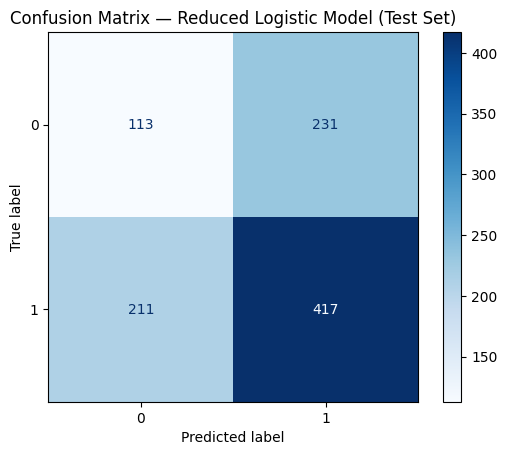

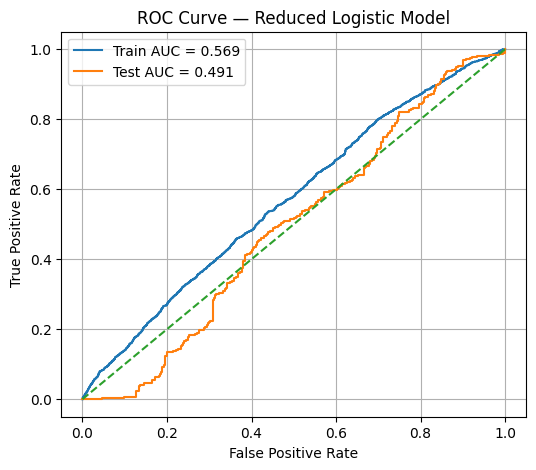

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix (Test)
cm = confusion_matrix(y2_test, y2_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix — Reduced Logistic Model (Test Set)")
plt.grid(False)
plt.show()

from sklearn.metrics import roc_curve, roc_auc_score

# Train probabilities
y2_train_proba = best_log2.predict_proba(X2_train_sc)[:, 1]

# ROC values
fpr_train, tpr_train, _ = roc_curve(y2_train, y2_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y2_test,  y2_test_proba)

# AUC
auc_train = roc_auc_score(y2_train, y2_train_proba)
auc_test  = roc_auc_score(y2_test,  y2_test_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test,  tpr_test,  label=f"Test AUC = {auc_test:.3f}")

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Reduced Logistic Model")
plt.legend()
plt.grid(True)
plt.show()

### Diving Deeper into ROC Curve
- LR's test AUC curve is coming below random (green dotted line) for FPR<=0.35. This means the model is unreliable for low FPR.
- For FPR above 0.35, the model is slightly better than random.
- For example, lets say FPR is 0.45 where the TPR is ~0.5, this implies that our model predicted 50% of true buy signals and made 45% losing buy signals which are essentially bad trades.
- From a trading perspective, the baseline model is unsuitable because false buy signals are high !

### Prediction Confidence Analysis — Reduced Logistic Model (Test Set)

- **Confidence vs Correctness:**  
  Correct predictions tend to have slightly higher confidence, but the spread is very similar across both correct and incorrect cases.  
  There are several wrong predictions with high confidence, which indicates the model is often confidently incorrect.

- **Confidence Distribution (Correct vs Wrong):**  
  A large portion of predictions are clustered near very high confidence (close to 1.0).  
  However, both correct and incorrect predictions appear in this region, showing that high confidence is not exclusive to correct predictions.

- **Accuracy by Confidence:**  
  High confidence region (y_probability ≥ 0.7 or ≤ 0.3) covers most samples (~90%) with accuracy ≈ 0.56.  
  Low confidence region has fewer samples (~10%) with accuracy ≈ 0.45.  

- **Key Takeaway:**  
  While higher confidence slightly improves accuracy, the difference is small.  
  Our model tends to assign high confidence even when predictions are wrong, so confidence alone is not a reliable indicator of correctness.


===== SAMPLE PREDICTIONS =====

   Actual  Predicted  Probability  Confidence  Correct
0       0          1     0.590730    0.181460    False
1       1          1     0.576937    0.153874     True
2       0          1     0.577049    0.154097    False
3       1          1     0.580078    0.160156     True
4       1          1     0.546909    0.093818     True


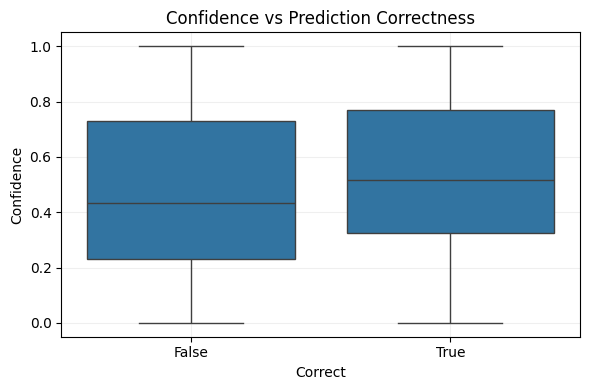

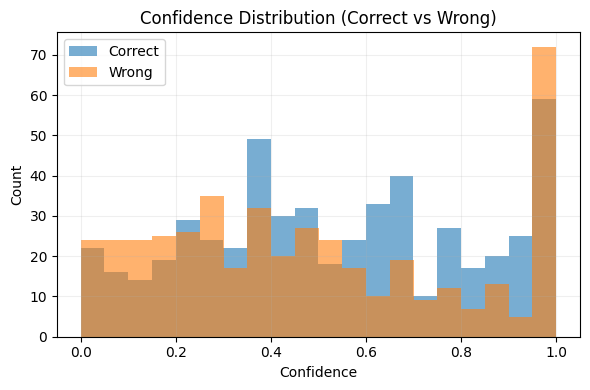


===== ACCURACY BY CONFIDENCE =====

High confidence (prob ≥ 0.7 or ≤ 0.3): 570 (58.6%)
Low confidence (0.3 < prob < 0.7): 402 (41.4%)

Accuracy — high confidence: 0.5877
Accuracy — low confidence: 0.4851


In [15]:
# ===== PREDICTION CONFIDENCE ANALYSIS (TEST SET — LOGISTIC) =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Probabilities (use calibrated if available) ----
y_prob = y2_test_proba
y_pred = y2_test_pred

# ---- Confidence (distance from 0.5, scaled to [0,1]) ----
confidence = np.abs(y_prob - 0.5) * 2

# ---- Results DataFrame ----
results_df = pd.DataFrame({
    "Actual": y2_test.values,
    "Predicted": y_pred,
    "Probability": y_prob,
    "Confidence": confidence
})

results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print("\n===== SAMPLE PREDICTIONS =====\n")
print(results_df.head())


# ===============================
# 1. CONFIDENCE vs CORRECTNESS
# ===============================
plt.figure(figsize=(6,4))
sns.boxplot(x="Correct", y="Confidence", data=results_df,showfliers=False)
plt.title("Confidence vs Prediction Correctness")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ===============================
# 2. DISTRIBUTION (CLEAN STYLE)
# ===============================
plt.figure(figsize=(6,4))

plt.hist(results_df[results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Correct")

plt.hist(results_df[~results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Wrong")

plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution (Correct vs Wrong)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ===============================
# 3. ACCURACY BY PROBABILITY BANDS
# ===============================
high_conf = (results_df["Probability"] >= 0.7) | (results_df["Probability"] <= 0.3)
low_conf  = (results_df["Probability"] > 0.3) & (results_df["Probability"] < 0.7)

acc_high = results_df[high_conf]["Correct"].mean()
acc_low  = results_df[low_conf]["Correct"].mean()

print("\n===== ACCURACY BY CONFIDENCE =====\n")
print(f"High confidence (prob ≥ 0.7 or ≤ 0.3): {high_conf.sum()} "
      f"({high_conf.mean()*100:.1f}%)")
print(f"Low confidence (0.3 < prob < 0.7): {low_conf.sum()} "
      f"({low_conf.mean()*100:.1f}%)")

print(f"\nAccuracy — high confidence: {acc_high:.4f}")
print(f"Accuracy — low confidence: {acc_low:.4f}")

## Conclusion

- **Baseline Model Performance:**  
  Logistic Regression was used as a linear baseline. Despite hyperparameter tuning and feature reduction, ranking ability remains near random with ROC-AUC **0.491 (full-feature)** → **0.491 (reduced-feature)**. Train AUC (~0.569) vs test AUC (~0.491) indicates weak generalisation of signal.

- **Limitation of Linear Modeling:**  
  - The linear decision boundary fails to capture the non-linear, regime-dependant relationships between technical indicators and 30 day forward returns. 
  - Features like RSI, CCI carry directional information only in context, high RSI in bullmarket is different than in a bear market.

- **Model Behavior (Class Bias):**  
  The model is biased toward predicting the positive class (upward movement)  
  Class 1 : **0.62**,
  Class 0 : **0.38**

- **Confidence Reliability:**  
  Predictions are heavily skewed toward high confidence:  
  - Accuracy: **0.588 (high confidence)** vs **0.485 (low confidence)**, High confidence accuracy is slightly higher but not relevant enough. 
  - Confidence distribution peaks near **1.0 for both correct and incorrect predictions** 
  .This indicates some degree of **overconfidence** 

- **Overall Insights:**  
  - The baseline logistic regression model shows negligible improvements on feature reduction and model-tuning fails. Near-random prediction power.
  - The LR model has almost 2X False positives than True negatives, 2X True Positives than false Negatives. This suggests a positive bias. Without **class_weight='balanced'** the model was only predicting positives. 
  - **ATR_pct, CCI, RSI_lag1** emerge as top 3 feature importances. All are volatility or oscillator based rather than trend following. This suggests that our model relies on extreme signals rather than directional momentum.
  - Capturing meaningful signals from technical indicators likely requires **nonlinear models** capable of regime aware feature interactions. This motivates us to pursue XGBoost and RandomForest which could potentially capture some directional signals.
  - From a business perspective, we deem the Logistic Regression model to be unsuitable for trading as it generates a lot of false buy signals. 